In [1]:
import kagglehub
sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-gaussian-filtered')

print('Data source import complete.')
print(sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path)

Data source import complete.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [5]:
# Répertoires
source_dir = '/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images'
target_dir = '/content/images'

# Dictionnaire de renommage
rename_dict = {
    'Mild': '1_Mild',
    'Moderate': '2_Moderate',
    'No_DR': '0_No_DR',
    'Proliferate_DR': '4_Proliferate_DR',
    'Severe': '3_Severe'
}

# Créer le dossier cible
os.makedirs(target_dir, exist_ok=True)

# Copier et renommer les dossiers
for old_name, new_name in rename_dict.items():
    old_path = os.path.join(source_dir, old_name)
    new_path = os.path.join(target_dir, new_name)

    if os.path.exists(old_path):
        shutil.copytree(old_path, new_path)
        print(f'Copié et renommé : {old_name} → {new_name}')
    else:
        print(f'Dossier introuvable : {old_path}')


FileExistsError: [Errno 17] File exists: '/content/images/1_Mild'

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/train.csv')

diagnosis_dict = {
    0: '0_No_DR',
    1: '1_Mild',
    2: '2_Moderate',
    3: '3_Severe',
    4: '4_Proliferate_DR',
}

path = '/content/images'
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
#df['filename'] = path + '/' + df['type'] + '/' + df['id_code'] + '.png'
df.head()

,id_code,diagnosis,type
0,000c1434d8d7,2,2_Moderate
1,001639a390f0,4,4_Proliferate_DR
2,0024cdab0c1e,1,1_Mild
3,002c21358ce6,0,0_No_DR
4,005b95c28852,0,0_No_DR


<Axes: ylabel='type'>

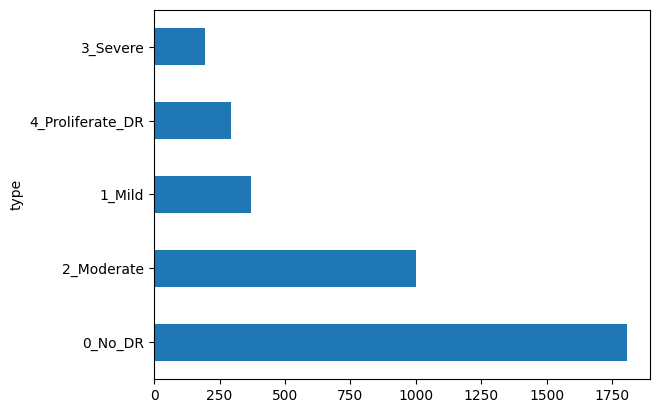

In [3]:
df['type'].value_counts().plot(kind='barh')

In [7]:
sdir=r'/content/images'
classlist=os.listdir(sdir)
filepaths=[]
labels=[]
for klass in classlist:
    classpath=os.path.join(sdir,klass)
    if os.path.isdir(classpath):
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
Fseries=pd.Series(filepaths, name='filepaths')
Lseries=pd.Series(labels, name='labels')
df=pd.concat([Fseries, Lseries], axis=1)
print (df.head())
print('df length: ', len(df))
print (df['labels'].value_counts())

                                  filepaths   labels
0  /content/images/0_No_DR/65f5d2a6eb7e.png  0_No_DR
1  /content/images/0_No_DR/4c635a01593d.png  0_No_DR
2  /content/images/0_No_DR/0a902c80d5da.png  0_No_DR
3  /content/images/0_No_DR/d6803e467592.png  0_No_DR
4  /content/images/0_No_DR/224c14366e11.png  0_No_DR
df length:  3662
labels
0_No_DR             1805
2_Moderate           999
1_Mild               370
4_Proliferate_DR     295
3_Severe             193
Name: count, dtype: int64


In [8]:
sample_list=[]
max_size= 1500
groups=df.groupby('labels')
for label in df['labels'].unique():
    group=groups.get_group(label)
    sample_count=len(group)
    if sample_count> max_size:
        samples=group.sample(max_size, replace=False, weights=None, random_state=123, axis=0).reset_index(drop=True)
    else:
        samples=group.sample(frac=1.0, replace=False, random_state=123, axis=0).reset_index(drop=True)
    sample_list.append(samples)
df=pd.concat(sample_list, axis=0).reset_index(drop=True)
print (len(df))
print (df['labels'].value_counts())

3357
labels
0_No_DR             1500
2_Moderate           999
1_Mild               370
4_Proliferate_DR     295
3_Severe             193
Name: count, dtype: int64


In [9]:
working_dir=r'./'
aug_dir=os.path.join(working_dir, 'aug')
if os.path.isdir(aug_dir):
    shutil.rmtree(aug_dir)
os.mkdir(aug_dir)
for label in df['labels'].unique():
    dir_path=os.path.join(aug_dir,label)
    os.mkdir(dir_path)
print(os.listdir(aug_dir))

['0_No_DR', '4_Proliferate_DR', '1_Mild', '3_Severe', '2_Moderate']


In [10]:
target=1500 # set the target count for each class in df
gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,
                              height_shift_range=.2, zoom_range=.2)
groups=df.groupby('labels') # group by class
for label in df['labels'].unique():  # for every class
    group=groups.get_group(label)  # a dataframe holding only rows with the specified label
    sample_count=len(group)   # determine how many samples there are in this class
    if sample_count< target: # if the class has less than target number of images
        aug_img_count=0
        delta=target-sample_count  # number of augmented images to create
        target_dir=os.path.join(aug_dir, label)  # define where to write the images
        aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=(224,224), class_mode=None,
                                        batch_size=1, shuffle=False, save_to_dir=target_dir, save_prefix='aug-',
                                        save_format='png')
        while aug_img_count<delta:
            images=next(aug_gen)
            aug_img_count += len(images)

Found 295 validated image filenames.
Found 370 validated image filenames.
Found 193 validated image filenames.
Found 999 validated image filenames.


In [11]:
aug=r'./aug'
auglist=os.listdir(aug)
print (auglist)
for klass in auglist:
    classpath=os.path.join(aug, klass)
    flist=os.listdir(classpath)
    print('class: ', klass, '  file count: ', len(flist))

['0_No_DR', '4_Proliferate_DR', '1_Mild', '3_Severe', '2_Moderate']
class:  0_No_DR   file count:  0
class:  4_Proliferate_DR   file count:  1205
class:  1_Mild   file count:  1130
class:  3_Severe   file count:  1307
class:  2_Moderate   file count:  501


In [12]:
aug_fpaths=[]
aug_labels=[]
classlist=os.listdir(aug_dir)
for klass in classlist:
    classpath=os.path.join(aug_dir, klass)
    flist=os.listdir(classpath)
    for f in flist:
        fpath=os.path.join(classpath,f)
        aug_fpaths.append(fpath)
        aug_labels.append(klass)
Fseries=pd.Series(aug_fpaths, name='filepaths')
Lseries=pd.Series(aug_labels, name='labels')
aug_df=pd.concat([Fseries, Lseries], axis=1)
ndf=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
#ndf=df.sample(frac=1.0, replace=False, random_state=123, axis=0).reset_index(drop=True)


print (df['labels'].value_counts())
print(aug_df['labels'].value_counts())
print (ndf['labels'].value_counts())

labels
0_No_DR             1500
2_Moderate           999
1_Mild               370
4_Proliferate_DR     295
3_Severe             193
Name: count, dtype: int64
labels
3_Severe            1307
4_Proliferate_DR    1205
1_Mild              1130
2_Moderate           501
Name: count, dtype: int64
labels
0_No_DR             1500
4_Proliferate_DR    1500
1_Mild              1500
3_Severe            1500
2_Moderate          1500
Name: count, dtype: int64


<Axes: ylabel='labels'>

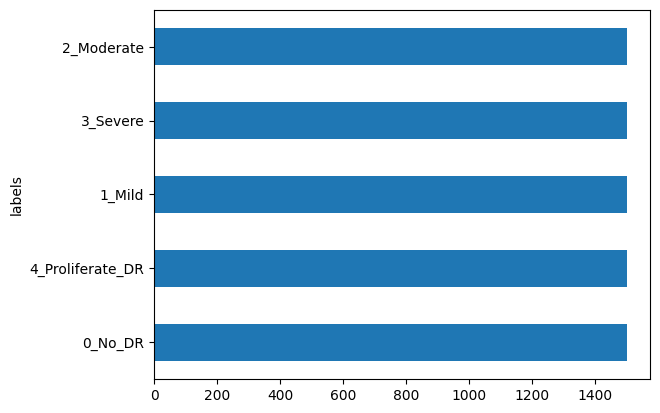

In [13]:
ndf['labels'].value_counts().plot(kind='barh')

In [14]:
ndf.head()

,filepaths,labels
0,/content/images/0_No_DR/de18071c36e6.png,0_No_DR
1,/content/images/0_No_DR/668a319c2d23.png,0_No_DR
2,/content/images/0_No_DR/3b5dffe159b6.png,0_No_DR
3,/content/images/0_No_DR/d99dd99be001.png,0_No_DR
4,/content/images/0_No_DR/ee3fe7809e6a.png,0_No_DR


In [15]:
train_intermediate, test = train_test_split(ndf, test_size = 0.1, stratify = ndf['labels'])
train, val = train_test_split(train_intermediate, test_size = 0.1 / (1 - 0.1), stratify = train_intermediate['labels'])

print("Train shape: ", train.shape)
print("Test shape: ",test.shape)
print("Valid shape: ", val.shape)

print(train['labels'].value_counts(), '\n')
print(test['labels'].value_counts(), '\n')
print(val['labels'].value_counts(), '\n')

Train shape:  (6000, 2)
Test shape:  (750, 2)
Valid shape:  (750, 2)
labels
2_Moderate          1200
4_Proliferate_DR    1200
3_Severe            1200
0_No_DR             1200
1_Mild              1200
Name: count, dtype: int64 

labels
1_Mild              150
4_Proliferate_DR    150
0_No_DR             150
2_Moderate          150
3_Severe            150
Name: count, dtype: int64 

labels
4_Proliferate_DR    150
2_Moderate          150
1_Mild              150
3_Severe            150
0_No_DR             150
Name: count, dtype: int64 



In [16]:
datagen = ImageDataGenerator(rescale=1./255)

train_batches = datagen.flow_from_dataframe(
    dataframe=train,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32
)

val_batches = datagen.flow_from_dataframe(
    dataframe=val,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32)

test_batches = datagen.flow_from_dataframe(
    dataframe=test,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False,
    batch_size=32)

Found 6000 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.


In [18]:
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

densenet = EfficientNetB5(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = tf.keras.Sequential()
model.add(densenet)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(5, activation='sigmoid'))

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=Adam(0.0001,decay=1e-6),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb5 (Functional)     │ (None, 7, 7, 2048)     │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,523,772 (108.81 MB)

 Trainable params: 28,351,029 (108.15 MB)

 Non-trainable params: 172,743 (674.78 KB)

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_batches,
                    epochs=50,
                    validation_data=val_batches,
                    callbacks=[reduce_lr, early_stop]
                    )

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.4830 - loss: 1.2246 - val_accuracy: 0.2773 - val_loss: 1.5823 - learning_rate: 1.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 494ms/step - accuracy: 0.7480 - loss: 0.6736 - val_accuracy: 0.3787 - val_loss: 1.4455 - learning_rate: 1.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 495ms/step - accuracy: 0.8757 - loss: 0.3658 - val_accuracy: 0.4627 - val_loss: 1.2451 - learning_rate: 1.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 494ms/step - accuracy: 0.9303 - loss: 0.1980 - val_accuracy: 0.6547 - val_loss: 1.0440 - learning_rate: 1.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 495ms/step - accuracy: 0.9604 - loss: 0.1177 - val_accuracy: 0.5733 - val_loss: 1.2750 - learning_rate: 1.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 493ms/step - accuracy: 0.9715 - loss: 0.0857 - val_accuracy: 0.5053 - val_loss: 1.5313 - learning_rate: 1.0000e-04
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 493m

In [20]:
model.save('EfficientNetB5_model.h5')

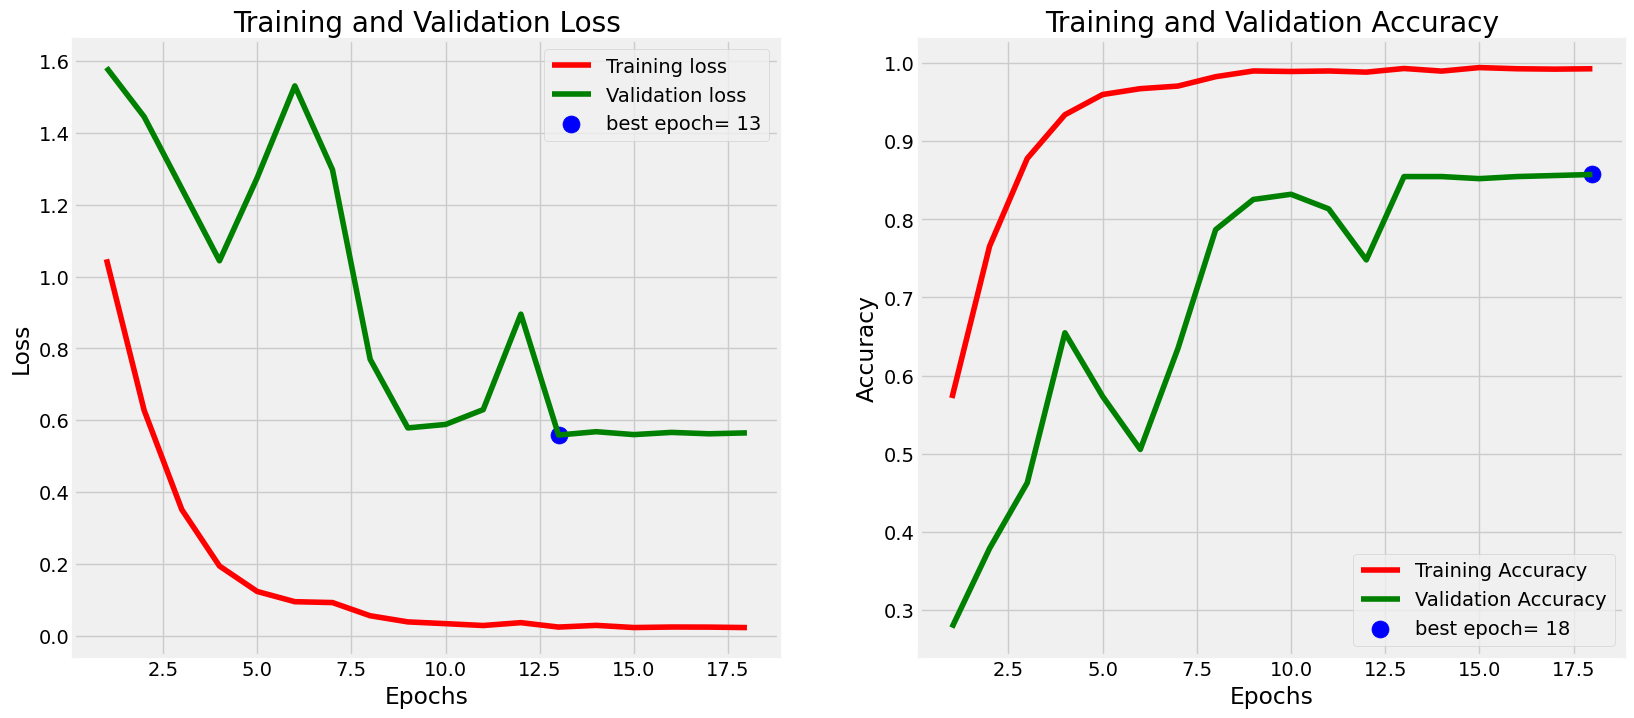

In [21]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [22]:
train_score = model.evaluate(train_batches, verbose= 1)
valid_score = model.evaluate(val_batches, verbose= 1)
test_score = model.evaluate(test_batches, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

188/188 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - accuracy: 0.9956 - loss: 0.0086
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8731 - loss: 0.5008
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.8509 - loss: 0.6179
Train Loss:  0.008943304419517517
Train Accuracy:  0.9958333373069763
--------------------
Validation Loss:  0.558654248714447
Validation Accuracy:  0.8546666502952576
--------------------
Test Loss:  0.6420296430587769
Test Accuracy:  0.8493333458900452


24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 620ms/step


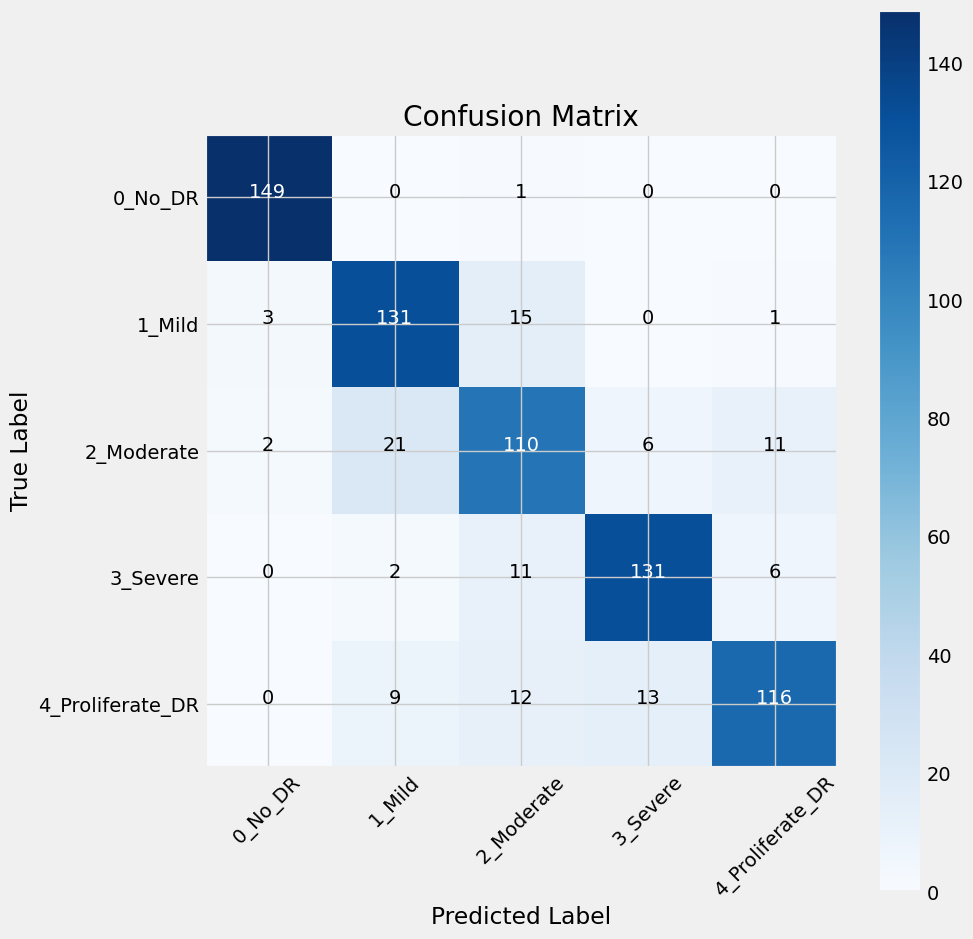

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

preds = model.predict(test_batches, steps=len(test_batches))
y_pred = np.argmax(preds, axis=1)

g_dict = test_batches.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_batches.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [24]:
# Classification report
print(classification_report(test_batches.classes, y_pred, target_names= classes))

                  precision    recall  f1-score   support

         0_No_DR       0.97      0.99      0.98       150
          1_Mild       0.80      0.87      0.84       150
      2_Moderate       0.74      0.73      0.74       150
        3_Severe       0.87      0.87      0.87       150
4_Proliferate_DR       0.87      0.77      0.82       150

        accuracy                           0.85       750
       macro avg       0.85      0.85      0.85       750
    weighted avg       0.85      0.85      0.85       750

